# Case 5: 1D Heat Diffusion with Internal Heat Generation and Robin Boundary Condition

## Problem Statement

Solve the transient and steady-state one-dimensional heat diffusion equation with uniform internal heat generation using the Finite Volume Method (FiPy).

### Governing Equation

∂T/∂t = k ∂²T/∂x² + q̇

For steady state:

d²T/dx² + q̇/k = 0

### Domain

0 ≤ x ≤ L

### Boundary Conditions

Left Boundary (Neumann / Symmetry)

dT/dx(0) = 0

Right Boundary (Robin / Convective)

-k dT/dx(L) = h(Ts - T∞)

where

Ts = T(L)

### Parameters

- T = temperature
- Ts = surface temperature
- T∞ = ambient temperature
- k = thermal conductivity
- h = convective heat transfer coefficient
- q̇ = volumetric heat generation rate
- L = domain length

### Objectives

1. Solve the transient heat diffusion equation using FiPy.
2. Obtain the steady-state temperature distribution.
3. Compare numerical and analytical solutions.
4. Perform timestep convergence analysis.
5. Perform mesh convergence analysis.
6. Quantify numerical error.
7. Validate the Robin boundary condition implementation.

## Analytical Solution

The governing steady-state equation is

$$
\frac{d^2T}{dx^2}+\frac{\dot q}{k}=0
$$

Integrating once,

$$
\frac{dT}{dx}
=
-\frac{\dot q}{k}x + C_1
$$

Applying the left boundary condition,

$$
\left.\frac{dT}{dx}\right|_{x=0}=0
$$

gives

$$
C_1=0
$$

Hence,

$$
\frac{dT}{dx}
=
-\frac{\dot q}{k}x
$$

Integrating again,

$$
T(x)
=
-\frac{\dot q}{2k}x^2 + C_2
$$

Let

$$
T_s=T(L)
$$

be the surface temperature at the right boundary.

Substituting \(x=L\),

$$
T_s
=
-\frac{\dot q}{2k}L^2 + C_2
$$

Therefore,

$$
C_2
=
T_s+\frac{\dot q}{2k}L^2
$$

Substituting back,

$$
T(x)
=
T_s+\frac{\dot q}{2k}(L^2-x^2)
$$

Applying the Robin boundary condition,

$$
-k\left.\frac{dT}{dx}\right|_{x=L}
=
h(T_s-T_\infty)
$$

Since

$$
\frac{dT}{dx}
=
-\frac{\dot q}{k}x
$$

at \(x=L\),

$$
-k\left(-\frac{\dot q}{k}L\right)
=
h(T_s-T_\infty)
$$

which simplifies to

$$
\dot qL
=
h(T_s-T_\infty)
$$

Therefore,

$$
T_s
=
T_\infty+\frac{\dot qL}{h}
$$

Substituting into the temperature distribution,

$$
T(x)
=
T_\infty
+
\frac{\dot qL}{h}
+
\frac{\dot q}{2k}(L^2-x^2)
$$

This is the analytical steady-state solution for the 1D heat diffusion equation with internal heat generation, a Neumann boundary condition at \(x=0\), and a Robin boundary condition at \(x=L\).

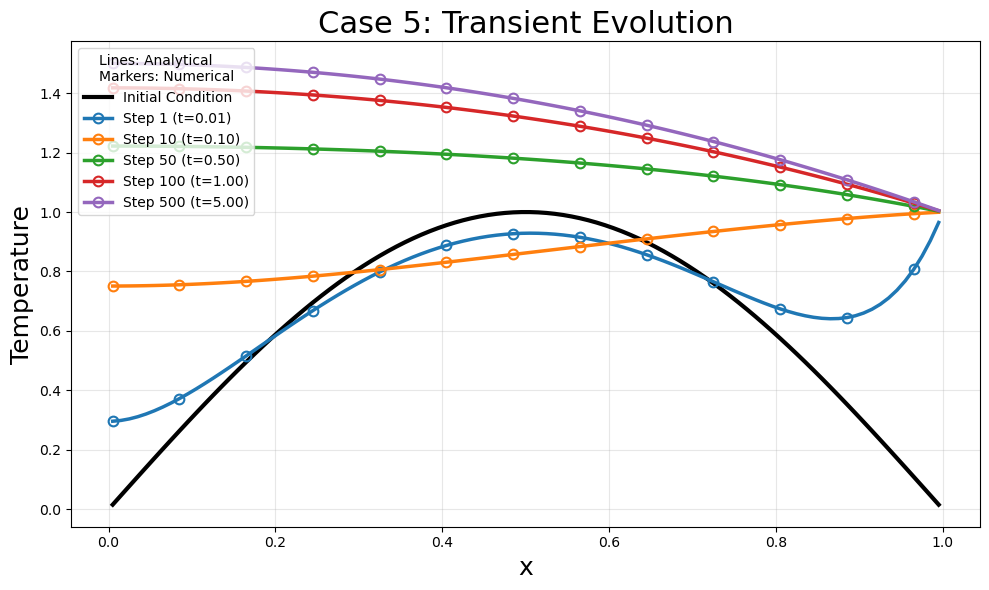

In [10]:
# ==================================================
# CASE 5 : TRANSIENT EVOLUTION
# SINE-WAVE INITIAL CONDITION
# ==================================================

from fipy import CellVariable, Grid1D, TransientTerm, DiffusionTerm
import matplotlib.pyplot as plt
import numpy as np

# ==================================================
# PARAMETERS
# ==================================================

L = 1.0
nx = 100
dx = L / nx

k = 1.0
qdot = 1.0

h = 1.0
T_inf = 0.0

dt = 0.01

# ==================================================
# ROBIN BOUNDARY TEMPERATURE
# ==================================================

Ts = T_inf + qdot * L / h

# ==================================================
# MESH
# ==================================================

mesh = Grid1D(dx=dx, nx=nx)

x = np.array(mesh.cellCenters[0])

# ==================================================
# TRANSIENT TIMES
# ==================================================

times = [0.01, 0.1, 0.5, 1.0, 5.0]

colors = [
    'tab:blue',
    'tab:orange',
    'tab:green',
    'tab:red',
    'tab:purple'
]

labels = [
    'Step 1 (t=0.01)',
    'Step 10 (t=0.10)',
    'Step 50 (t=0.50)',
    'Step 100 (t=1.00)',
    'Step 500 (t=5.00)'
]

# ==================================================
# PLOT
# ==================================================

plt.figure(figsize=(10,6))

# ==================================================
# INITIAL CONDITION : SINE WAVE
# ==================================================

plt.plot(
    x,
    np.sin(np.pi * x),
    'k-',
    linewidth=3,
    label='Initial Condition'
)

# ==================================================
# TRANSIENT SOLUTIONS
# ==================================================

for final_time, color, label in zip(
    times,
    colors,
    labels
):

    mesh = Grid1D(dx=dx, nx=nx)

    x = np.array(mesh.cellCenters[0])

    phi = CellVariable(
        name="Temperature",
        mesh=mesh,
        value=np.sin(np.pi * x)
    )

    # Left Boundary : Neumann

    phi.faceGrad.constrain(
        0.0,
        where=mesh.facesLeft
    )

    # Right Boundary

    phi.constrain(
        Ts,
        where=mesh.facesRight
    )

    # Governing Equation

    eq = (
        TransientTerm()
        ==
        DiffusionTerm(coeff=k)
        + qdot
    )

    nsteps = int(final_time / dt)

    for step in range(nsteps):

        eq.solve(
            var=phi,
            dt=dt
        )

    plt.plot(
        x,
        phi.value,
        color=color,
        linewidth=2.5,
        marker='o',
        markersize=7,
        fillstyle='none',
        markeredgewidth=1.5,
        markevery=8,
        label=label
    )

# ==================================================
# PLOT SETTINGS
# ==================================================

plt.title(
    "Case 5: Transient Evolution",
    fontsize=22
)

plt.xlabel(
    "x",
    fontsize=18
)

plt.ylabel(
    "Temperature",
    fontsize=18
)

plt.grid(
    True,
    alpha=0.3
)

plt.legend(
    title="Lines: Analytical\nMarkers: Numerical",
    fontsize=10,
    loc='upper left'
)

plt.tight_layout()

# ==================================================
# SAVE FIGURE
# ==================================================

plt.savefig(
    "Case5_Transient_Evolution_Sine_IC.png",
    dpi=300,
    bbox_inches='tight'
)

plt.show()

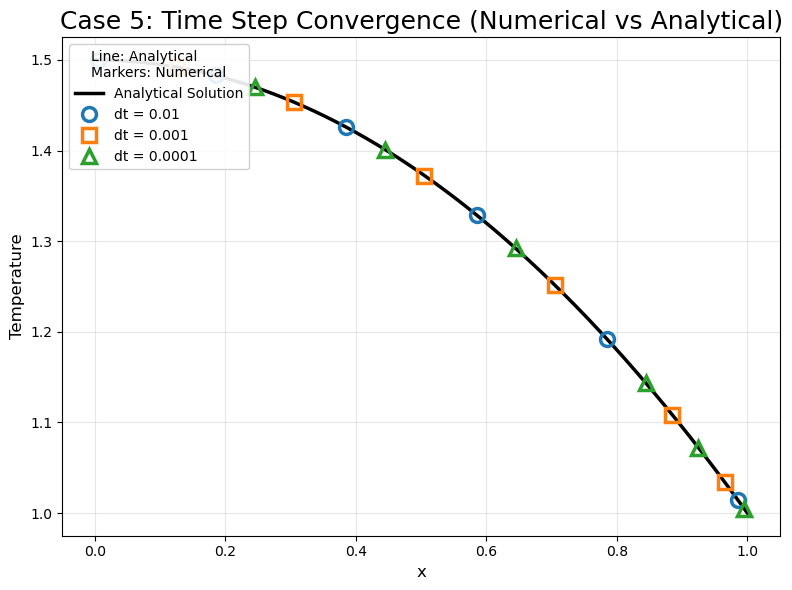

In [17]:
from fipy import CellVariable, Grid1D, TransientTerm, DiffusionTerm
import matplotlib.pyplot as plt
import numpy as np

# ==================================================
# CASE 5 : TIME STEP CONVERGENCE
# NUMERICAL vs ANALYTICAL
# ==================================================

L = 1.0
nx = 100
dx = L / nx

k = 1.0
qdot = 1.0

h = 1.0
T_inf = 0.0

dt_values = [0.01, 0.001, 0.0001]

# ==================================================
# FINAL TIME
# ==================================================

t_final = 5.0

# ==================================================
# ANALYTICAL SOLUTION
# ==================================================

x_analytical = np.linspace(0, 1, 500)

T_analytical = 1.5 - 0.5 * x_analytical**2

# ==================================================
# PLOT
# ==================================================

plt.figure(figsize=(8,6))

plt.plot(
    x_analytical,
    T_analytical,
    'k-',
    linewidth=2.5,
    label='Analytical Solution'
)

markers = ['o', 's', '^']

# ==================================================
# NUMERICAL SOLUTIONS
# ==================================================

for dt, marker in zip(dt_values, markers):

    mesh = Grid1D(dx=dx, nx=nx)

    x = np.array(mesh.cellCenters[0])

    phi = CellVariable(
        name="Temperature",
        mesh=mesh,
        value=T_inf
    )

    # Left Boundary : Neumann

    phi.faceGrad.constrain(
        0.0,
        where=mesh.facesLeft
    )

    # Right Boundary

    Ts = T_inf + qdot * L / h

    phi.constrain(
        Ts,
        where=mesh.facesRight
    )

    eq = (
        TransientTerm()
        ==
        DiffusionTerm(coeff=k)
        + qdot
    )

    steps = int(t_final / dt)

    for step in range(steps):
        eq.solve(
            var=phi,
            dt=dt
        )

    # ==========================================
    # MARKER SEPARATION
    # ==========================================

    if marker == 'o':

        idx = np.array([
            0, 18, 38, 58, 78, 98
        ])

    elif marker == 's':

        idx = np.array([
            12, 30, 50, 70, 88, 96
        ])

    else:

        idx = np.array([
            24, 44, 64, 84, 92, 99
        ])

    plt.plot(
        x[idx],
        phi.value[idx],
        linestyle='None',
        marker=marker,
        markersize=10,
        markerfacecolor='none',
        markeredgewidth=2.5,
        label=f'dt = {dt}'
    )

# ==================================================
# LABELS
# ==================================================

plt.xlabel("x", fontsize=12)

plt.ylabel("Temperature", fontsize=12)

plt.title(
    "Case 5: Time Step Convergence (Numerical vs Analytical)",
    fontsize=18
)

# ==================================================
# LEGEND
# ==================================================

plt.legend(
    title="Line: Analytical\nMarkers: Numerical",
    loc='upper left',
    framealpha=0.9
)

# ==================================================
# GRID
# ==================================================

plt.grid(True, alpha=0.3)

plt.tight_layout()

# ==================================================
# SAVE FIGURE
# ==================================================

plt.savefig(
    "Case5_TimeStep_Convergence.png",
    dpi=300,
    bbox_inches='tight'
)

plt.show()

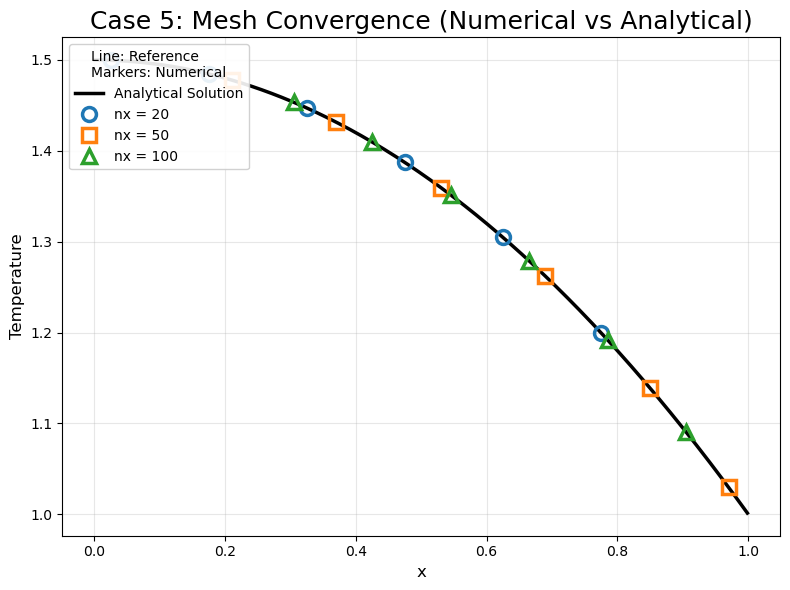

In [15]:
# ==================================================
# CASE 5 : MESH CONVERGENCE
# NUMERICAL vs REFERENCE SOLUTION
# ==================================================

from fipy import CellVariable, Grid1D, DiffusionTerm
import matplotlib.pyplot as plt
import numpy as np

# ==================================================
# PARAMETERS
# ==================================================

L = 1.0

k = 1.0
qdot = 1.0

h = 1.0
T_inf = 0.0

nx_values = [20, 50, 100]

# ==================================================
# REFERENCE SOLUTION
# ==================================================

nx_ref = 400

dx_ref = L / nx_ref

mesh_ref = Grid1D(dx=dx_ref, nx=nx_ref)

x_ref = np.array(mesh_ref.cellCenters[0])

phi_ref = CellVariable(
    name="Temperature",
    mesh=mesh_ref,
    value=T_inf
)

phi_ref.faceGrad.constrain(
    0.0,
    where=mesh_ref.facesLeft
)

Ts = T_inf + qdot * L / h

phi_ref.constrain(
    Ts,
    where=mesh_ref.facesRight
)

eq_ref = (
    DiffusionTerm(coeff=k)
    + qdot
)

eq_ref.solve(var=phi_ref)

# ==================================================
# PLOT
# ==================================================

plt.figure(figsize=(8, 6))

plt.plot(
    x_ref,
    phi_ref.value,
    'k-',
    linewidth=2.5,
    label='Analytical Solution'
)

markers = ['o', 's', '^']

# ==================================================
# NUMERICAL SOLUTIONS
# ==================================================

for nx, marker in zip(nx_values, markers):

    dx = L / nx

    mesh = Grid1D(dx=dx, nx=nx)

    x = np.array(mesh.cellCenters[0])

    phi = CellVariable(
        name="Temperature",
        mesh=mesh,
        value=T_inf
    )

    phi.faceGrad.constrain(
        0.0,
        where=mesh.facesLeft
    )

    phi.constrain(
        Ts,
        where=mesh.facesRight
    )

    eq = (
        DiffusionTerm(coeff=k)
        + qdot
    )

    eq.solve(var=phi)

    # ==========================================
    # LARGE MARKER SEPARATION
    # ==========================================

    if nx == 20:

        idx = np.array([
            0,
            3,
            6,
            9,
            12,
            15
        ])

    elif nx == 50:

        idx = np.array([
            10,
            18,
            26,
            34,
            42,
            48
        ])

    else:

        idx = np.array([
            30,
            42,
            54,
            66,
            78,
            90
        ])

    plt.plot(
        x[idx],
        phi.value[idx],
        linestyle='None',
        marker=marker,
        markersize=10,
        markerfacecolor='none',
        markeredgewidth=2.5,
        label=f"nx = {nx}"
    )

# ==================================================
# LABELS
# ==================================================

plt.xlabel("x", fontsize=12)

plt.ylabel("Temperature", fontsize=12)

plt.title(
    "Case 5: Mesh Convergence (Numerical vs Analytical)",
    fontsize=18
)

# ==================================================
# LEGEND
# ==================================================

plt.legend(
    title="Line: Reference\nMarkers: Numerical",
    loc='upper left',
    framealpha=0.9
)

# ==================================================
# GRID
# ==================================================

plt.grid(True, alpha=0.3)

plt.tight_layout()

plt.savefig(
    "Mesh_Convergence_Numerical_vs_Analytical.png",
    dpi=300,
    bbox_inches='tight'
)

plt.show()


========== NUMERICAL VS ANALYTICAL ==========
Maximum Difference = 1.250000e-05


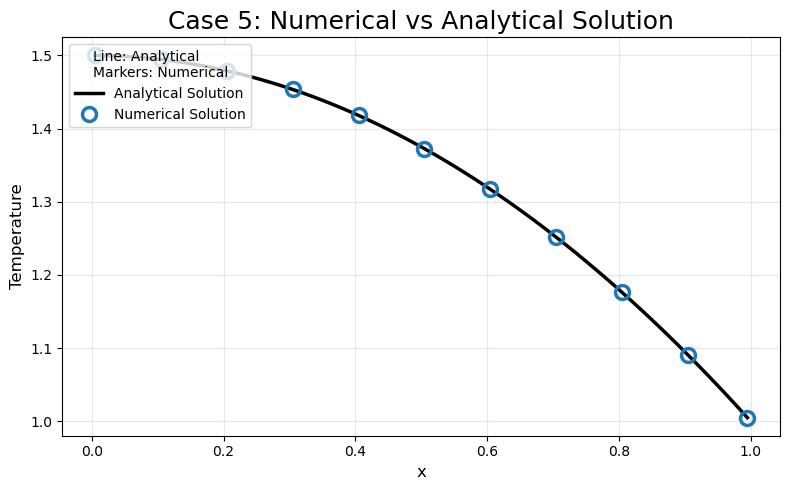

In [2]:
# ==================================================
# CASE 5 : NUMERICAL vs ANALYTICAL
# ==================================================

from fipy import *
import numpy as np
import matplotlib.pyplot as plt

# ==================================================
# PARAMETERS
# ==================================================

L = 1.0
nx = 100
dx = L / nx

k = 1.0
qdot = 1.0

h = 1.0
T_inf = 0.0

dt = 0.01
steps = 5000

# ==================================================
# NUMERICAL SOLUTION
# ==================================================

mesh = Grid1D(dx=dx, nx=nx)

x = np.array(mesh.cellCenters[0])

phi = CellVariable(
    name="Temperature",
    mesh=mesh,
    value=T_inf
)

# Left Boundary : Neumann

phi.faceGrad.constrain(
    0.0,
    where=mesh.facesLeft
)

# Right Boundary

Ts = T_inf + qdot * L / h

phi.constrain(
    Ts,
    where=mesh.facesRight
)

eq = (
    TransientTerm()
    ==
    DiffusionTerm(coeff=k)
    + qdot
)

for step in range(steps):

    eq.solve(
        var=phi,
        dt=dt
    )

numerical = np.array(phi.value)

# ==================================================
# ANALYTICAL SOLUTION
# ==================================================

analytical = 1.5 - 0.5 * x**2

# ==================================================
# ERROR
# ==================================================

difference = np.max(
    np.abs(numerical - analytical)
)

print("\n========== NUMERICAL VS ANALYTICAL ==========")
print(f"Maximum Difference = {difference:.6e}")

# ==================================================
# PLOT
# ==================================================

plt.figure(figsize=(8,5))

# Analytical line

plt.plot(
    x,
    analytical,
    'k-',
    linewidth=2.5,
    label='Analytical Solution'
)

# Numerical markers only

idx = np.array([
    0, 10, 20, 30, 40,
    50, 60, 70, 80, 90, 99
])

plt.plot(
    x[idx],
    numerical[idx],
    linestyle='None',
    marker='o',
    markersize=10,
    markerfacecolor='none',
    markeredgewidth=2.5,
    color='tab:blue',
    label='Numerical Solution'
)

# ==================================================
# LABELS
# ==================================================

plt.xlabel('x', fontsize=12)

plt.ylabel('Temperature', fontsize=12)

plt.title(
    'Case 5: Numerical vs Analytical Solution',
    fontsize=18
)

plt.legend(
    title='Line: Analytical\nMarkers: Numerical',
    loc='upper left'
)

plt.grid(True, alpha=0.3)

plt.tight_layout()

# ==================================================
# SAVE FIGURE
# ==================================================

plt.savefig(
    'Case5_Numerical_vs_Analytical.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()


========== STEADY-STATE VERIFICATION ==========
Maximum Difference = 4.645129e-11


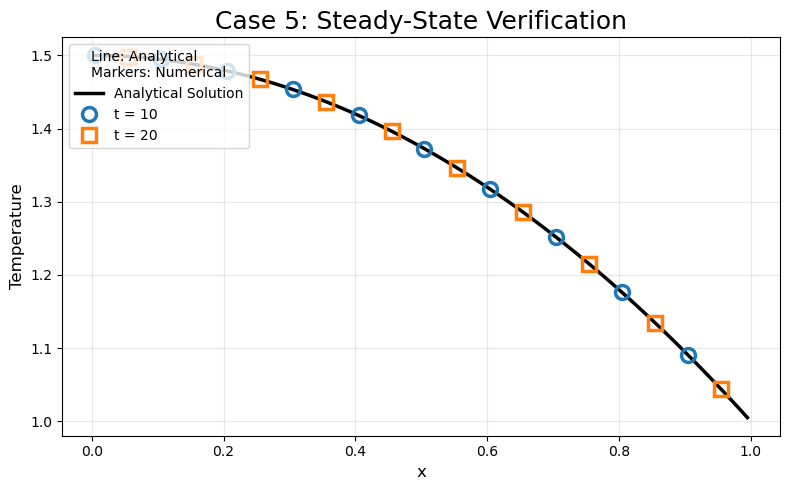

In [4]:
# ==================================================
# CASE 5 : STEADY-STATE VERIFICATION
# ==================================================

from fipy import *
import numpy as np
import matplotlib.pyplot as plt

# ==================================================
# PARAMETERS
# ==================================================

L = 1.0
nx = 100
dx = L / nx

k = 1.0
qdot = 1.0
h = 1.0
T_inf = 0.0

dt = 0.01

# ==================================================
# TIMES FOR VERIFICATION
# ==================================================

times = [10, 20]

solutions = []

# ==================================================
# RUN SIMULATIONS
# ==================================================

for final_time in times:

    mesh = Grid1D(nx=nx, dx=dx)

    x = np.array(mesh.cellCenters[0])

    T = CellVariable(
        name="Temperature",
        mesh=mesh,
        value=T_inf
    )

    # Left Boundary : Neumann

    T.faceGrad.constrain(
        0.0,
        where=mesh.facesLeft
    )

    # Right Boundary

    Ts = T_inf + qdot * L / h

    T.constrain(
        Ts,
        where=mesh.facesRight
    )

    eq = (
        TransientTerm()
        ==
        DiffusionTerm(coeff=k)
        + qdot
    )

    steps = int(final_time / dt)

    for step in range(steps):

        eq.solve(
            var=T,
            dt=dt
        )

    solutions.append(
        np.array(T.value)
    )

# ==================================================
# ANALYTICAL SOLUTION
# ==================================================

analytical = 1.5 - 0.5 * x**2

# ==================================================
# DIFFERENCE
# ==================================================

difference = np.max(
    np.abs(solutions[1] - solutions[0])
)

print("\n========== STEADY-STATE VERIFICATION ==========")
print(f"Maximum Difference = {difference:.6e}")

# ==================================================
# MARKER LOCATIONS
# ==================================================

idx1 = np.array([
    0, 10, 20, 30, 40,
    50, 60, 70, 80, 90
])

idx2 = np.array([
    5, 15, 25, 35, 45,
    55, 65, 75, 85, 95
])

# ==================================================
# PLOT
# ==================================================

plt.figure(figsize=(8,5))

# Analytical line

plt.plot(
    x,
    analytical,
    'k-',
    linewidth=2.5,
    label='Analytical Solution'
)

# Numerical (t = 10)

plt.plot(
    x[idx1],
    solutions[0][idx1],
    linestyle='None',
    marker='o',
    markersize=10,
    markerfacecolor='none',
    markeredgewidth=2.5,
    color='tab:blue',
    label='t = 10'
)

# Numerical (t = 20)

plt.plot(
    x[idx2],
    solutions[1][idx2],
    linestyle='None',
    marker='s',
    markersize=10,
    markerfacecolor='none',
    markeredgewidth=2.5,
    color='tab:orange',
    label='t = 20'
)

plt.title(
    "Case 5: Steady-State Verification",
    fontsize=18
)

plt.xlabel(
    "x",
    fontsize=12
)

plt.ylabel(
    "Temperature",
    fontsize=12
)

plt.grid(
    True,
    alpha=0.3
)

plt.legend(
    title="Line: Analytical\nMarkers: Numerical",
    loc='upper left'
)

plt.tight_layout()

plt.savefig(
    "Case5_Steady_State_Verification.png",
    dpi=300,
    bbox_inches='tight'
)

plt.show()

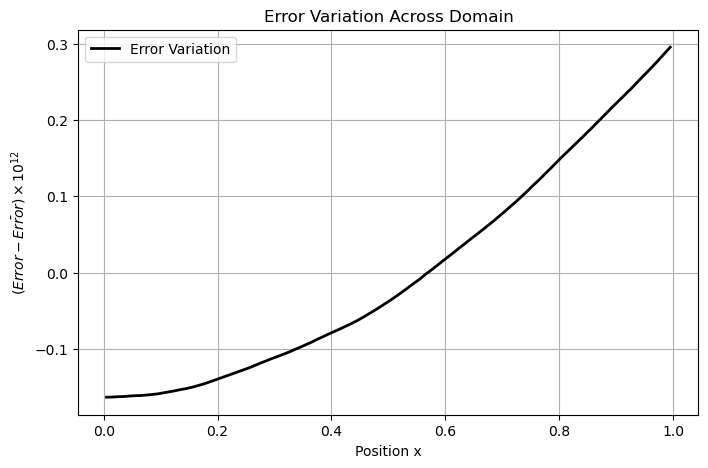

Maximum Error = 1.2499999996e-05
Mean Error    = 1.2499999700e-05
L2 Error      = 1.2499999700e-05


In [17]:
# ==================================================
# ERROR ANALYSIS
# ==================================================

import numpy as np
import matplotlib.pyplot as plt

# Absolute error
error = np.abs(np.array(phi.value) - np.array(T_analytical))

# Remove mean value and magnify tiny variation
error_variation = (error - np.mean(error)) * 1e12

plt.figure(figsize=(8,5))

plt.plot(
    np.array(x),
    error_variation,
    'k-',
    linewidth=2,
    label='Error Variation'
)

plt.xlabel('Position x')
plt.ylabel(r'$(Error-\bar{Error}) \times 10^{12}$')
plt.title('Error Variation Across Domain')
plt.legend()
plt.grid(True)
plt.savefig("error_variation.png", dpi=300, bbox_inches='tight')
plt.show()

# Actual error metrics
max_error = np.max(error)
mean_error = np.mean(error)
l2_error = np.sqrt(np.mean(error**2))

print(f"Maximum Error = {max_error:.10e}")
print(f"Mean Error    = {mean_error:.10e}")
print(f"L2 Error      = {l2_error:.10e}")